# Training a small DNA language model — from zero, with real data

This is a complete, runnable tutorial. By the end you will have **downloaded a real genome, tokenized it, built a Transformer from scratch in PyTorch, trained it, and generated new DNA** — and you'll understand every step.

**No prior ML required.** Every technical term is explained the first time it appears. You do need to be comfortable running Python cells.

**What we are building:** a model that reads DNA (a long string of the letters `A`, `C`, `G`, `T`) and learns to predict the next letter. That "predict the next token" objective is exactly how ChatGPT-style models work — we are just doing it on the language of the genome instead of English.

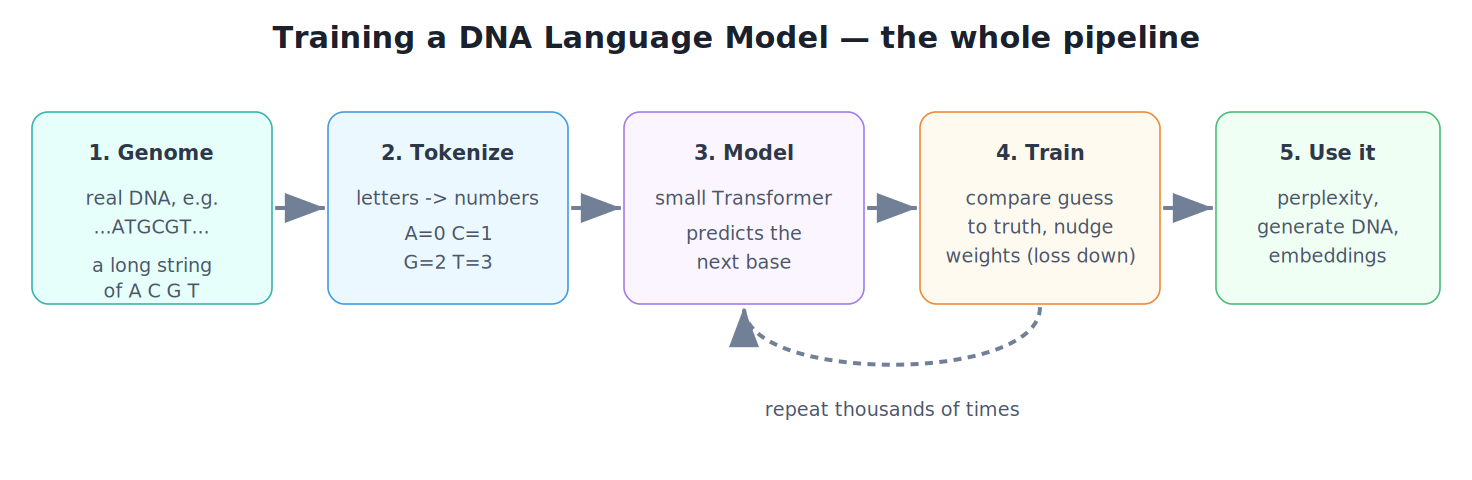

**Runtime:** everything here runs on a plain **CPU in a few minutes** (the defaults are deliberately small). A GPU (e.g. free Google Colab) makes it faster and lets you scale up — see the last section.


## 0. How to run this

- **Google Colab (easiest):** upload this notebook, then `Runtime → Run all`. For a GPU pick `Runtime → Change runtime type → T4 GPU` (optional).
- **Locally:** `pip install torch matplotlib requests` then run top to bottom.

The next cell installs what we need. If a package is already there, it's a no-op.

In [16]:
#pip install torch matplotlib requests

In [17]:
# Fix duplicate OpenMP runtime crash (libomp conflict on macOS with Anaconda)
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Install dependencies (safe to re-run)
import sys, subprocess
for pkg in ["torch", "matplotlib", "requests"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import torch, torch.nn as nn
from torch.nn import functional as F
import requests, math, time
from collections import Counter
import matplotlib.pyplot as plt

torch.manual_seed(1337)   # reproducibility: same random numbers every run

# Device priority: CUDA (NVIDIA) → MPS (Apple Silicon) → CPU
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("PyTorch", torch.__version__, "| device available:", device)


PyTorch 2.11.0 | device available: mps


### SIDENOTE: Kernel Crash Fix — `OMP: Error #15`,

If the kernel crashes immediately when importing `torch` on **macOS with Anaconda**, the cause is a duplicate OpenMP runtime (`libomp.dylib`). Anaconda bundles its own copy of `libomp`, and PyTorch links another — when both load into the same process, the runtime aborts with:

```
OMP: Error #15: Initializing libomp.dylib, but found libomp.dylib already initialized.
zsh: abort. this occured when I was trying to run the previous cell.
```

**Fix (applied in the cell above):** set the environment variable before importing torch:

```python
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
```

This suppresses the abort. It is an officially **unsupported workaround** — the proper long-term fix is to use a clean conda environment (`conda install pytorch -c pytorch`) to resolve the conflict, but for a tutorial notebook this is safe.

---

**Device selection order used here:** CUDA (NVIDIA GPU) → MPS (Apple M-series GPU) → CPU


## 1. What is a "DNA language model"? (concepts first)

**DNA** is a molecule that stores the instructions for building a living thing. For our purposes it's just a very long text written in a **4-letter alphabet**:

| letter | base    |
|--------|---------|
| `A`    | adenine |
| `C`    | cytosine|
| `G`    | guanine |
| `T`    | thymine |

A **genome** is the full DNA text of an organism. The human genome is ~3.2 **billion** letters; a bacterium ~4 million; the human *mitochondrial* genome (which we'll use as a warm-up) is a tidy **16,569** letters.

A **language model (LM)** is a program that learns the statistical patterns of a text so it can assign a probability to what comes next. An English LM learns that after "the cat sat on the" the word "mat" is likely. A **DNA language model** learns that after `ATG` certain bases are likely — because DNA, like language, is full of grammar-like structure (genes, regulatory motifs, codons, repeats).

**Why bother?** Trained DNA LMs (real research models: DNABERT, Nucleotide Transformer, HyenaDNA, Evo) are used to predict which mutations are harmful, find genes and regulatory regions, and classify sequences — often without task-specific labels, just from having "read" enough DNA. We're building a miniature version of the same idea.

**Key terms you'll meet:**
- **Token** — the smallest unit the model reads. For us, one token = one DNA base.
- **Vocabulary** — the set of possible tokens. Ours has size 4 (`A C G T`).
- **Model / weights / parameters** — the millions of adjustable numbers the model tunes during training.
- **Loss** — a single number measuring how wrong the model's predictions are. Training = making loss go down.
- **Perplexity** — a human-friendly version of loss; roughly "how many bases is the model effectively guessing between." Lower is better; 4.0 means random guessing for us.

## 2. Get real genome data

We download two **real** genomes straight from public files on GitHub (no login, works anywhere):

1. **Human mitochondrial genome** (16,569 bp) — a complete, famous, small genome. Great for looking at.
2. ***C. elegans* (roundworm) genome fragment** (~1 million bp) — enough real sequence to actually train on.

`bp` = *base pairs* = length of the sequence in letters. A `.fa` / FASTA file just stores sequences as: a header line starting with `>`, then the letters.

In [2]:
# --- download two real genomes ---
URLS = {
    "MT_human": "https://raw.githubusercontent.com/lh3/minimap2/master/test/MT-human.fa",
    "c_elegans": "https://raw.githubusercontent.com/samtools/htslib/develop/test/ce.fa",
}

def download(url):
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.text

def parse_fasta(text):
    """Return {sequence_name: sequence_string}. Uppercases everything."""
    seqs, name = {}, None
    for line in text.splitlines():
        line = line.strip()
        if line.startswith(">"):
            name = line[1:].split()[0]
            seqs[name] = []
        elif line:
            seqs[name].append(line)
    # real genomes use lowercase for 'soft-masked' (repetitive) regions -> uppercase them
    return {k: "".join(v).upper() for k, v in seqs.items()}

raw = {k: download(u) for k, u in URLS.items()}
mt   = parse_fasta(raw["MT_human"])
ce   = parse_fasta(raw["c_elegans"])

mt_seq = "".join(mt.values())
print("Human mitochondrial genome:", f"{len(mt_seq):,} bp")
print("First 80 bases:", mt_seq[:80])
print()
print("C. elegans fragment:", f"{sum(len(s) for s in ce.values()):,} bp",
      "across", len(ce), "sequences:", list(ce.keys()))

Human mitochondrial genome: 16,569 bp
First 80 bases: GATCACAGGTCTATCACCCTATTAACCACTCACGGGAGCTCTCCATGCATTTGGTATTTTCGTCTGGGGGGTATGCACGC

C. elegans fragment: 1,039,800 bp across 7 sequences: ['CHROMOSOME_I', 'CHROMOSOME_II', 'CHROMOSOME_III', 'CHROMOSOME_IV', 'CHROMOSOME_V', 'CHROMOSOME_X', 'CHROMOSOME_MtDNA']


## 3. Explore the data (know your input before modeling)

Two quick sanity checks every genomicist does:

- **Base composition** — how often each letter appears. Real DNA is *not* uniform.
- **GC content** — the percentage of `G`+`C`. It varies by organism and region and is biologically meaningful (affects DNA stability, gene density).

Human MT genome base counts: {'A': 5125, 'C': 5181, 'G': 2169, 'T': 4094}
GC content: 44.4%


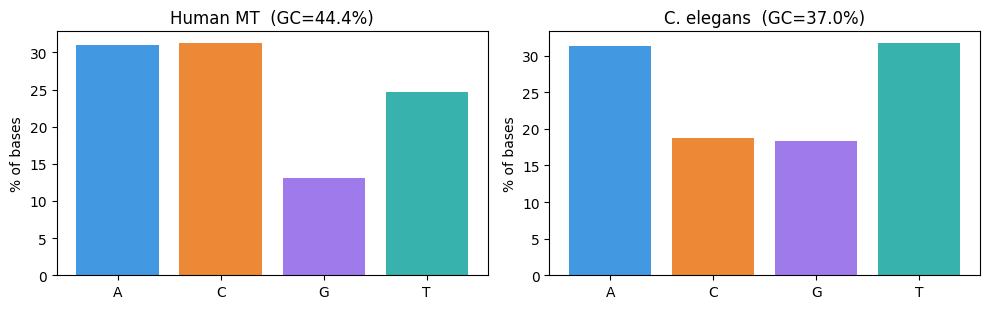

In [3]:
def composition(seq):
    c = Counter(seq)
    total = sum(c.values())
    return {b: c[b] for b in "ACGT"}, total

comp, total = composition(mt_seq)
gc = 100 * (comp["G"] + comp["C"]) / total
print("Human MT genome base counts:", comp)
print(f"GC content: {gc:.1f}%")

# bar chart of composition for both genomes
ce_seq_all = "".join(ce.values())
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, (name, seq) in zip(axes, [("Human MT", mt_seq), ("C. elegans", ce_seq_all)]):
    comp, tot = composition(seq)
    ax.bar(comp.keys(), [comp[b]/tot*100 for b in "ACGT"],
           color=["#4299e1", "#ed8936", "#9f7aea", "#38b2ac"])
    ax.set_title(f"{name}  (GC={(comp['G']+comp['C'])/tot*100:.1f}%)")
    ax.set_ylabel("% of bases")
plt.tight_layout(); plt.show()

Notice the letters are unevenly used and the two organisms differ. **A model that only memorized these frequencies would already beat random guessing** — we'll use that as our baseline later, so we can prove our Transformer learns something *beyond* mere letter frequencies.

## 4. Tokenization — turning letters into numbers

Neural networks eat numbers, not letters. **Tokenization** maps each token to an integer ID. We use the simplest scheme: **character-level** — one base, one number.

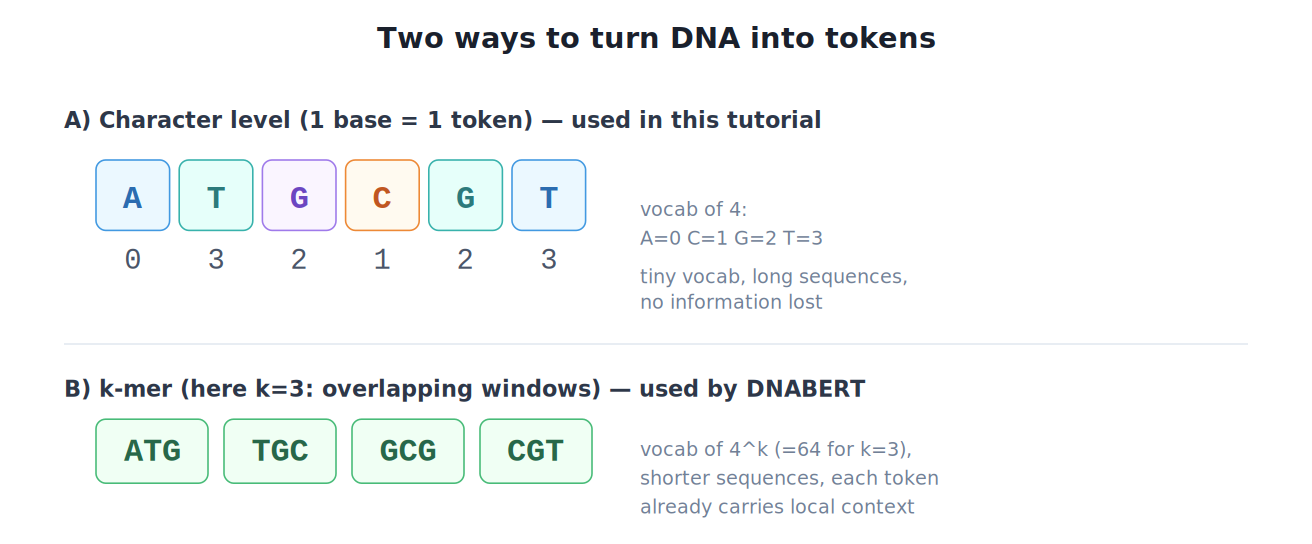

We use **character-level** (option A) because it's the simplest, loses no information, and is exactly what modern DNA models like HyenaDNA and Evo use. (Option B, **k-mer** tokenization, groups `k` bases into one token; DNABERT uses it. It's mentioned so you know it exists.)

In [4]:
# Build the vocabulary from the data itself
train_source = ce_seq_all          # we'll train on the C. elegans sequence
chars = sorted(set(train_source))  # the distinct letters present
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}   # string -> integer
itos = {i: ch for ch, i in stoi.items()}       # integer -> string

encode = lambda s: [stoi[c] for c in s]        # "ATG" -> [0, 3, 2]
decode = lambda ids: "".join(itos[i] for i in ids)

print("Vocabulary:", chars, "  size:", vocab_size)
print("encode('ATGC') =", encode("ATGC"))
print("decode(...)    =", decode(encode("ATGC")))

Vocabulary: ['A', 'C', 'G', 'T']   size: 4
encode('ATGC') = [0, 3, 2, 1]
decode(...)    = ATGC


## 5. The task, and how we feed data to the model

The model's only job: **given the bases so far, predict the next base.**

We can't feed a million bases at once, so we work in fixed-length windows called **`block_size`** (the *context length* — how far back the model can see). For every position in a window, the correct answer (**target**) is simply the *next* base. So the target is the input shifted left by one:

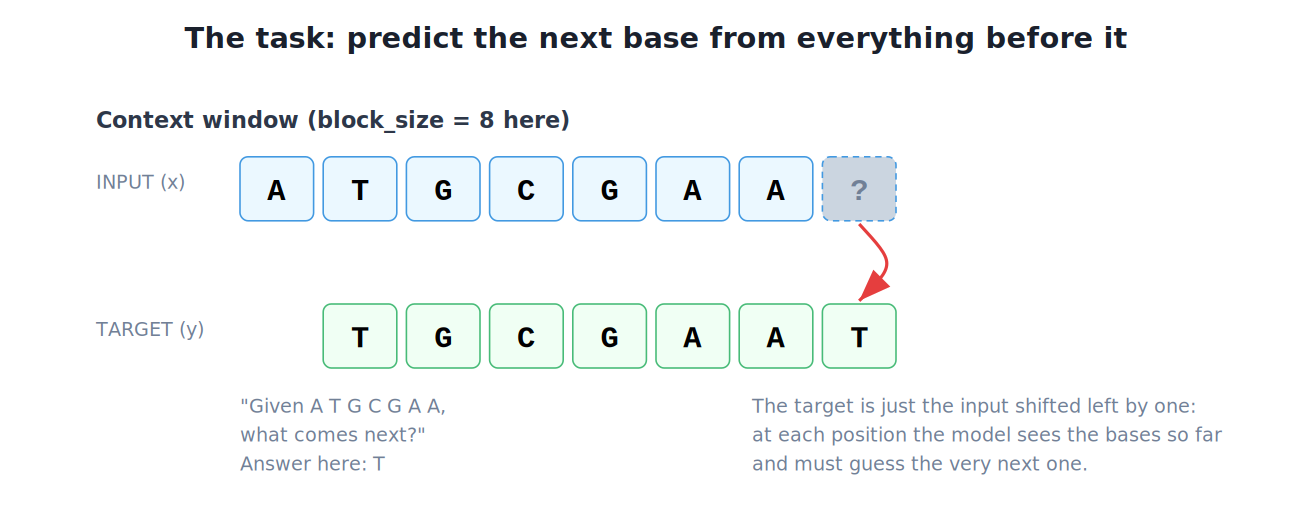

We also split data into **training** (used to learn) and **validation** (held out, used only to check honest performance on unseen sequence). And we grab several windows at a time — a **batch** — for efficiency.

In [5]:
# encode the whole training sequence once, as a tensor of integers
data = torch.tensor(encode(train_source), dtype=torch.long)

# 90% train / 10% validation
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"train: {len(train_data):,} bases   val: {len(val_data):,} bases")

block_size = 64   # context length: how many bases the model sees at once
batch_size = 32   # how many windows we process in parallel

def get_batch(split):
    d = train_data if split == "train" else val_data
    # pick batch_size random start positions
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size]       for i in ix])   # inputs
    y = torch.stack([d[i+1:i+block_size+1]   for i in ix])   # targets = shifted by 1
    return x.to(device), y.to(device)

# Device priority: CUDA (NVIDIA) → MPS (Apple Silicon) → CPU
#if torch.cuda.is_available():
#    device = "cuda"
#elif torch.backends.mps.is_available():
#    device = "mps"
#else:
#    device = "cpu"

xb, yb = get_batch("train")
print("input batch shape:", tuple(xb.shape), "= (batch_size, block_size)")
print("one input window :", decode(xb[0].tolist()))
print("its target window:", decode(yb[0].tolist()), " <- shifted by one base")
print("Device used is :", device)

train: 935,820 bases   val: 103,980 bases
input batch shape: (32, 64) = (batch_size, block_size)
one input window : CTCAAAAATAAGGAAGATTTTTGGAAAAACAAAAATTGCTGGCCGACAGCTGGAAAAAACTCGG
its target window: TCAAAAATAAGGAAGATTTTTGGAAAAACAAAAATTGCTGGCCGACAGCTGGAAAAAACTCGGC  <- shifted by one base
Device used is : mps


## 6. Build the model from scratch

We build a **Transformer** — the architecture behind essentially all modern LMs. Rather than import a black box, we write it in ~50 lines so nothing is hidden. Here is what each piece does, in plain terms.

**a) Embeddings.** Each token ID (0-3) is turned into a vector of `n_embd` learnable numbers — its "meaning" slot. We also add a **positional embedding** so the model knows *where* in the window each base sits (order matters in DNA).

**b) Self-attention.** The core idea. For each position, the model looks back at earlier positions and decides *which ones are relevant* to predicting the next base, then mixes their information. This is how it captures patterns like "this looks like the start of a repeat 10 bases back." Multiple **heads** let it attend to several kinds of patterns at once.

**c) Causal mask.** Because we predict the *next* base, a position must **never see the future** — only itself and earlier positions. We enforce this with a triangular mask:

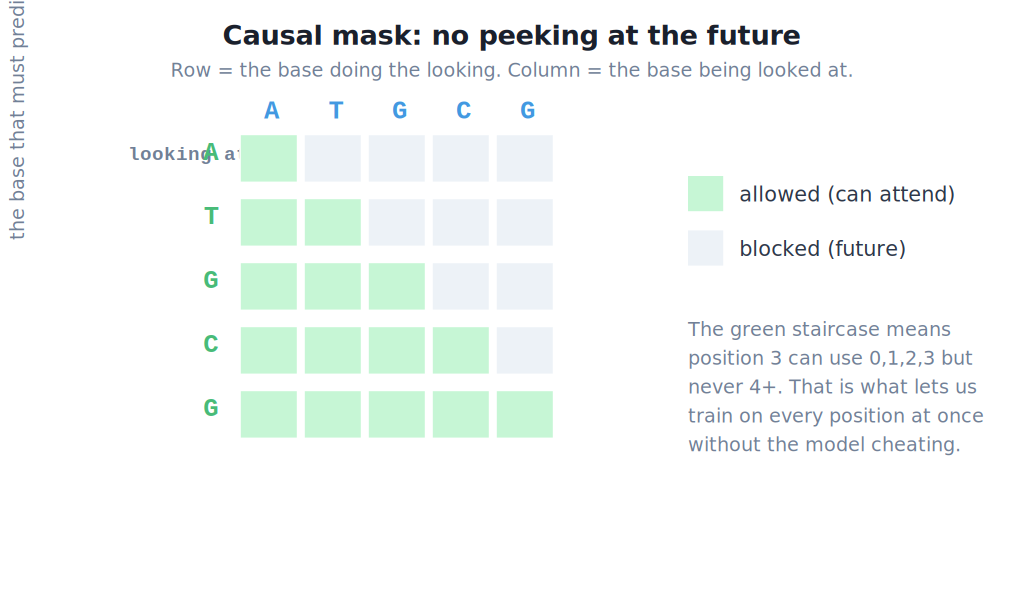

**d) The block.** Attention + a small **feed-forward network** (per-position processing), each wrapped with a **residual connection** (add the input back, which helps deep networks train) and **LayerNorm** (keeps numbers well-scaled). We stack several blocks.

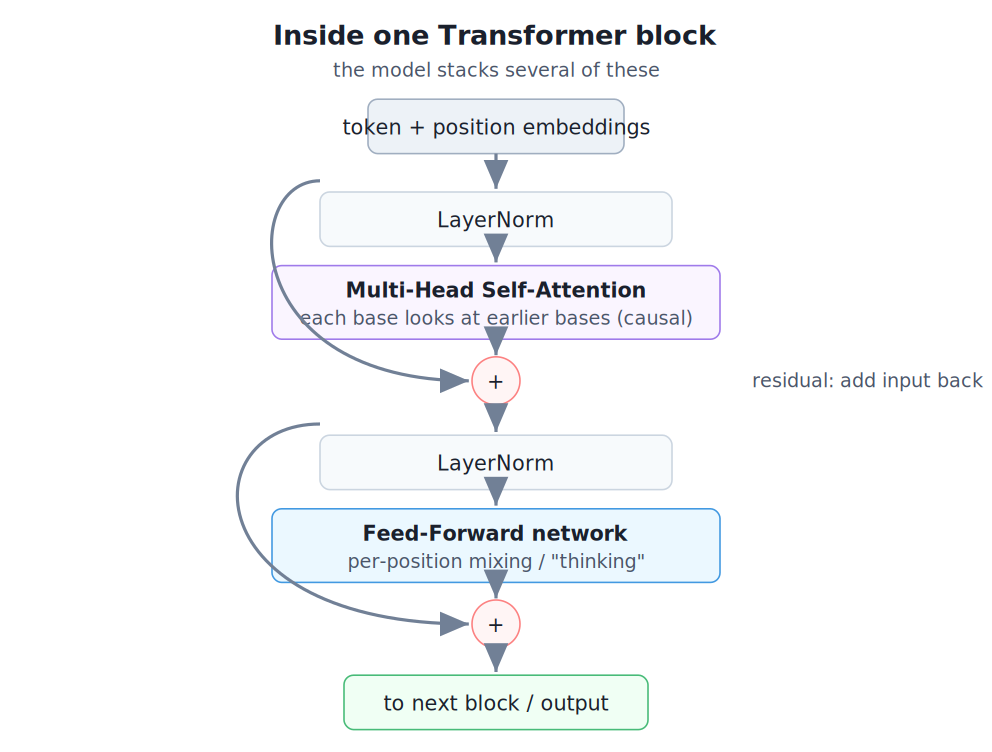

We'll define the pieces bottom-up: `Head` -> `MultiHeadAttention` -> `FeedForward` -> `Block` -> full `DNAGPT`.

### 6a. Configuration (small on purpose — trains in minutes on CPU)

In [6]:
# --- model + training hyperparameters ---
n_embd   = 96    # size of each token's vector
n_head   = 3     # number of attention heads (n_embd must divide by n_head)
n_layer  = 3     # number of stacked Transformer blocks
dropout  = 0.1   # randomly zero 10% of activations during training (prevents overfitting)

max_iters     = 3000    # training steps  (bump to 3000+ on a GPU for better results)
eval_interval = 300    # how often to check validation loss
eval_iters    = 30     # how many batches to average when measuring loss
learning_rate = 3e-3   # how big a step the optimizer takes

print(f"device = {device}")

device = mps


### 6b. One attention head

In [7]:
class Head(nn.Module):
    """A single self-attention head."""
    def __init__(self, head_size):
        super().__init__()
        # each token produces a key, a query, and a value vector
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # lower-triangular matrix used as the causal mask (not a learned parameter)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape                       # batch, time (positions), channels
        k = self.key(x)                         # (B, T, head_size)
        q = self.query(x)
        # attention scores: how much each position attends to each other position
        wei = q @ k.transpose(-2, -1) * k.shape[-1]**-0.5    # (B, T, T)
        # causal mask: forbid attending to future positions
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)            # turn scores into weights that sum to 1
        wei = self.dropout(wei)
        return wei @ self.value(x)              # weighted sum of value vectors

### 6c. Multi-head attention, feed-forward, and a full block

In [8]:
class MultiHeadAttention(nn.Module):
    """Several attention heads in parallel, then combined."""
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj  = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)   # glue heads together
        return self.dropout(self.proj(out))

class FeedForward(nn.Module):
    """Per-position processing: expand, non-linearity, contract."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd), nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd), nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)

class Block(nn.Module):
    """Transformer block: attention + feed-forward, each with residual + LayerNorm."""
    def __init__(self):
        super().__init__()
        self.sa  = MultiHeadAttention(n_head, n_embd // n_head)
        self.ff  = FeedForward()
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
    def forward(self, x):
        x = x + self.sa(self.ln1(x))    # residual around attention
        x = x + self.ff(self.ln2(x))    # residual around feed-forward
        return x

In [ ]:
import os
from matplotlib.patches import FancyBboxPatch

os.makedirs("docs/figures", exist_ok=True)

# ── Color palette (matches project theme) ─────────────────────
BG     = '#0d1117'; TEXT   = '#e6edf3'; MUT    = '#8b949e'
BORD   = '#30363d'; BLUE   = '#4299e1'; ORANGE = '#ed8936'
PURPLE = '#9f7aea'; TEAL   = '#38b2ac'; GREEN  = '#3fb950'

fig, ax = plt.subplots(figsize=(6, 11.5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
ax.set_xlim(0, 6); ax.set_ylim(1.2, 12.8); ax.axis('off')
CX, BW, BH = 3.0, 4.6, 0.56   # center-x, box-width, box-height

def draw_box(y, label, sub='', col=BLUE):
    ax.add_patch(FancyBboxPatch(
        (CX - BW/2, y - BH/2), BW, BH,
        boxstyle='round,pad=0.04',
        fc=col + '22', ec=col, lw=1.5, zorder=3))
    dy = 0.10 if sub else 0
    ax.text(CX, y + dy, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color=TEXT, zorder=4)
    if sub:
        ax.text(CX, y - dy - 0.01, sub, ha='center', va='center',
                fontsize=6.8, color=MUT, zorder=4)

def draw_arrow(y0, y1):
    ax.annotate('', xy=(CX, y1), xytext=(CX, y0),
                arrowprops=dict(arrowstyle='->', color=BORD, lw=1.5))

def draw_residual_note(y):
    ax.text(CX - BW/2 - 0.48, y, '+ residual',
            ha='center', va='center', fontsize=7, color=GREEN, style='italic')

# ── Input ──────────────────────────────────────────────────────
ax.text(CX, 12.40, 'Input :   A  T  G  C  A  T  G  C  …',
        ha='center', va='center', fontsize=9, color=MUT, style='italic')
draw_arrow(12.12, 11.76)

# ── Embeddings ─────────────────────────────────────────────────
draw_box(11.45, 'Token Embedding',
         f'vocab_size ({vocab_size})  →  n_embd ({n_embd})', TEAL)
draw_arrow(11.17, 10.80)
draw_box(10.50, 'Positional Encoding',
         f'positions  0 … {block_size - 1}   (block_size = {block_size})', TEAL)
draw_arrow(10.22, 9.74)

# ── Transformer block dashed outline ───────────────────────────
BT, BB = 9.64, 5.52
ax.add_patch(FancyBboxPatch(
    (CX - BW/2 - 0.26, BB - 0.18), BW + 0.52, BT - BB + 0.36,
    boxstyle='round,pad=0.05', fc='none', ec=BORD,
    lw=1.0, ls='--', zorder=1))
ax.text(CX - BW/2 - 0.26, BT + 0.22,
        'Transformer Block', ha='left', va='bottom',
        fontsize=7.5, color=MUT, style='italic')
ax.text(CX + BW/2 + 0.16, (BT + BB) / 2,
        f'× {n_layer}', ha='left', va='center',
        fontsize=10, color=MUT, style='italic')

# ── Block internals ────────────────────────────────────────────
draw_box(9.33, 'Layer Norm', '', PURPLE)
draw_arrow(9.05, 8.68)
draw_box(8.37, 'Multi-Head Causal Self-Attention',
         f'{n_head} heads × {n_embd // n_head}-dim   |   causal mask (no future tokens)', BLUE)
draw_arrow(8.09, 7.82)
draw_residual_note(7.68)
draw_arrow(7.58, 7.22)
draw_box(6.91, 'Layer Norm', '', PURPLE)
draw_arrow(6.63, 6.26)
draw_box(5.95, 'Feed-Forward  (Linear → ReLU → Linear)',
         f'{n_embd}  →  {4 * n_embd}  →  {n_embd}', ORANGE)
draw_arrow(5.67, 5.42)
draw_residual_note(5.28)

# ── After block ────────────────────────────────────────────────
draw_arrow(5.20, 4.84)
draw_box(4.53, 'Layer Norm  (final)', '', PURPLE)
draw_arrow(4.25, 3.88)
draw_box(3.57, 'Linear  (Language Model Head)',
         f'n_embd ({n_embd})  →  vocab_size ({vocab_size})', TEAL)
draw_arrow(3.29, 2.92)
draw_box(2.61, 'Softmax  →  next-base probabilities',
         'P(A)   P(C)   P(G)   P(T)', GREEN)
draw_arrow(2.33, 1.97)
ax.text(CX, 1.74, 'A: 0.08   C: 0.27   G: 0.41   T: 0.24',
        ha='center', va='center',
        fontsize=8.5, color=MUT, family='monospace')

ax.set_title('DNAGPT  —  Transformer Architecture',
             color=TEXT, fontsize=12, pad=12, fontweight='bold')

plt.tight_layout()
plt.savefig('docs/figures/transformer_architecture.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved → docs/figures/transformer_architecture.png')


### 6d. The full model

In [9]:
class DNAGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding    = nn.Embedding(vocab_size, n_embd)   # meaning of each base
        self.position_embedding = nn.Embedding(block_size, n_embd)   # meaning of each position
        self.blocks = nn.Sequential(*[Block() for _ in range(n_layer)])
        self.ln_f   = nn.LayerNorm(n_embd)
        self.head   = nn.Linear(n_embd, vocab_size)   # maps to a score per possible next base

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.token_embedding(idx)                                  # (B, T, n_embd)
        pos = self.position_embedding(torch.arange(T, device=idx.device))
        x = tok + pos
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.head(x)                                            # (B, T, vocab_size)
        loss = None
        if targets is not None:
            # cross-entropy: penalizes putting low probability on the correct next base
            loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        """Autoregressively sample new bases, one at a time."""
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -block_size:])     # only last block_size fit in context
            probs = F.softmax(logits[:, -1, :], dim=-1)  # probabilities for the next base
            idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
        return idx

model = DNAGPT().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model ready: {n_params:,} parameters ({n_params/1e6:.2f}M)")

Model ready: 341,764 parameters (0.34M)


## 7. Baselines — so "good" means something

**Perplexity** is our score. Definition: `perplexity = exp(cross-entropy loss)`. Intuition: it's the effective number of equally-likely choices the model is stuck between. Two reference points:

- **Uniform guessing:** if the model knew nothing, it would guess each of the 4 bases equally -> perplexity **4.0**.
- **Base-composition guessing:** if it only knew each letter's overall frequency (Section 3) -> perplexity ~**3.87** for this genome.

Our Transformer must beat **both** to prove it learned real sequence structure (dependencies between bases), not just letter frequencies.

In [10]:
cnt = Counter(train_source)
tot = sum(cnt.values())
uniform_ppl = float(vocab_size)
entropy = -sum((v/tot) * math.log(v/tot) for v in cnt.values())
unigram_ppl = math.exp(entropy)
print(f"Uniform baseline perplexity        : {uniform_ppl:.3f}")
print(f"Base-composition baseline perplexity: {unigram_ppl:.3f}")

Uniform baseline perplexity        : 4.000
Base-composition baseline perplexity: 3.866


## 8. Train the model

Training loop, one step at a time:
1. grab a batch of windows,
2. the model predicts next-base probabilities and computes the **loss**,
3. **backpropagation** figures out how to nudge every weight to reduce the loss,
4. the **optimizer** (AdamW) applies the nudge.

Repeat `max_iters` times. We periodically measure train & validation loss so we can watch learning happen. On CPU with the default settings this takes roughly **2-3 minutes**.

In [11]:
@torch.no_grad()
def estimate_loss():
    """Average loss over several batches, for train and val (model in eval mode)."""
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            _, loss = model(*get_batch(split))
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

history = []
t0 = time.time()
for it in range(max_iters + 1):
    if it % eval_interval == 0:
        L = estimate_loss()
        history.append((it, L["train"], L["val"]))
        print(f"iter {it:4d} | train loss {L['train']:.4f} | "
              f"val loss {L['val']:.4f} | val perplexity {math.exp(L['val']):.3f} "
              f"| {time.time()-t0:.0f}s")
    xb, yb = get_batch("train")
    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()          # backpropagation
    optimizer.step()         # update weights
print("Done.")

iter    0 | train loss 1.5547 | val loss 1.5487 | val perplexity 4.705 | 0s
iter  300 | train loss 1.3130 | val loss 1.3276 | val perplexity 3.772 | 4s
iter  600 | train loss 1.3007 | val loss 1.3161 | val perplexity 3.729 | 7s
iter  900 | train loss 1.2935 | val loss 1.3041 | val perplexity 3.685 | 11s
iter 1200 | train loss 1.2937 | val loss 1.3010 | val perplexity 3.673 | 14s
iter 1500 | train loss 1.2923 | val loss 1.2993 | val perplexity 3.667 | 17s
iter 1800 | train loss 1.2996 | val loss 1.2866 | val perplexity 3.621 | 21s
iter 2100 | train loss 1.2911 | val loss 1.2866 | val perplexity 3.621 | 24s
iter 2400 | train loss 1.2780 | val loss 1.2838 | val perplexity 3.610 | 27s
iter 2700 | train loss 1.2887 | val loss 1.2804 | val perplexity 3.598 | 31s
iter 3000 | train loss 1.2854 | val loss 1.2704 | val perplexity 3.562 | 34s
Done.


**Plot the learning curve** and compare against the baselines:

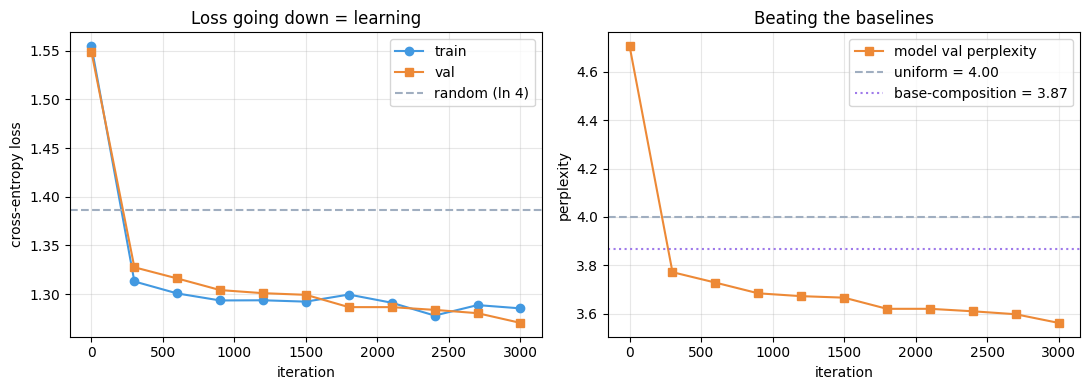

In [ ]:
its   = [h[0] for h in history]
trl   = [h[1] for h in history]
val   = [h[2] for h in history]

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4))
a.plot(its, trl, "o-", label="train", color="#4299e1")
a.plot(its, val, "s-", label="val",   color="#ed8936")
a.axhline(math.log(4), ls="--", color="#a0aec0", label="random (ln 4)")
a.set_xlabel("iteration"); a.set_ylabel("cross-entropy loss"); a.legend(); a.grid(alpha=.3)
a.set_title("Loss going down = learning")

b.plot(its, [math.exp(v) for v in val], "s-", color="#ed8936", label="model val perplexity")
b.axhline(uniform_ppl, ls="--", color="#a0aec0", label=f"uniform = {uniform_ppl:.2f}")
b.axhline(unigram_ppl, ls=":",  color="#9f7aea", label=f"base-composition = {unigram_ppl:.2f}")
b.set_xlabel("iteration"); b.set_ylabel("perplexity"); b.legend(); b.grid(alpha=.3)
b.set_title("Beating the baselines")
plt.tight_layout()
os.makedirs("docs/figures", exist_ok=True)
plt.savefig("docs/figures/loss_perplexity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → docs/figures/loss_perplexity.png")


*result:* validation perplexity drops from ~4.9 to about **3.5 ish**, clearly under both the uniform (4.0) and base-composition (~3.87) baselines. That gap is the model demonstrably learning real dependencies between bases — not just their frequencies. It plateaus fairly quickly because this is a tiny model on a hard, high-entropy signal; scaling up (next section) pushes it lower.

This is a small model, there is still room for improvement but seems like this is still a good start.

## 9. Evaluate: final perplexity on held-out DNA

We report perplexity on the **validation** set — sequence the model never trained on — so the number reflects genuine generalization, not memorization.

In [13]:
L = estimate_loss()
print(f"Final validation loss      : {L['val']:.4f}")
print(f"Final validation perplexity: {math.exp(L['val']):.3f}")
print(f"(uniform baseline {uniform_ppl:.2f}, base-composition {unigram_ppl:.2f})")

Final validation loss      : 1.2718
Final validation perplexity: 3.567
(uniform baseline 4.00, base-composition 3.87)


## 10. Generate new DNA

Because the model predicts next-base probabilities, we can **sample** from it repeatedly to hallucinate new sequence — the DNA equivalent of autocomplete. We seed it with a start codon `ATG` and let it continue.

In [14]:
context = torch.tensor([encode("ATG")], dtype=torch.long, device=device)
generated = decode(model.generate(context, max_new_tokens=300)[0].tolist())
print("Generated 300 bases:\n")
print("\n".join(generated[i:i+60] for i in range(0, len(generated), 60)))

Generated 300 bases:

ATGCTTTGTCATATACATTTTCTACTGGACTGCTATAATTCCCGATTCCAGTCTTAGGGA
CATTTTGGCCAATCCTGTTTGGCAAGGGTGTAGTTTTTGGTCGACCTTCCCGACGTAGGG
AGATGTTTTGCGTGTGCGAGGAGTGATGTTTTTTGTTGGAGTTTTTAAATTTAACGAAAA
ATTTTTCAGTGCTACGTGCATGTCATTAAAATCTCGTCTTTAACTATGTCCACGTCCATT
TTTCGGAGATTAAGGACGATTTCCACGGTTATTCTACTAATTTGAAGCCCTAAAGAAGTC
TCG


## 11. Did it actually learn biology-like structure?

A perplexity number is abstract. Let's *see* what the model learned by comparing the **3-mer** (3-base-word) frequencies of real DNA vs. DNA the model generates. If the model captured local structure, these distributions should look similar.

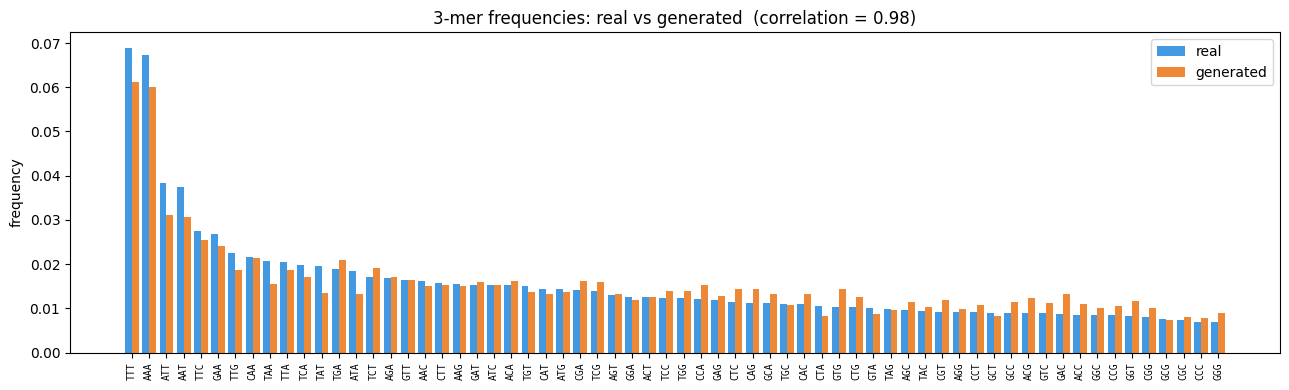

3-mer frequency correlation (real vs generated): 0.98
GC content — real: 37.0%   generated: 40.3%


In [ ]:
def kmer_freq(seq, k=3):
    c = Counter(seq[i:i+k] for i in range(len(seq)-k+1))
    t = sum(c.values())
    return {kk: v/t for kk, v in c.items()}

long_gen = decode(model.generate(
    torch.tensor([encode("ATG")], dtype=torch.long, device=device), 6000)[0].tolist())

real_f = kmer_freq(train_source[:200_000])
gen_f  = kmer_freq(long_gen)
keys   = sorted(real_f, key=lambda x: -real_f[x])

import numpy as np
rv = [real_f[k] for k in keys]
gv = [gen_f.get(k, 0) for k in keys]
corr = np.corrcoef(rv, gv)[0, 1]

x = np.arange(len(keys))
plt.figure(figsize=(13, 4))
plt.bar(x-0.2, rv, 0.4, label="real", color="#4299e1")
plt.bar(x+0.2, gv, 0.4, label="generated", color="#ed8936")
plt.xticks(x, keys, rotation=90, fontsize=7, family="monospace")
plt.ylabel("frequency"); plt.legend()
plt.title(f"3-mer frequencies: real vs generated  (correlation = {corr:.2f})")
plt.tight_layout()
os.makedirs("docs/figures", exist_ok=True)
plt.savefig("docs/figures/kmer_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → docs/figures/kmer_comparison.png")

print(f"3-mer frequency correlation (real vs generated): {corr:.2f}")
print(f"GC content — real: {100*(train_source.count('G')+train_source.count('C'))/len(train_source):.1f}%"
      f"   generated: {100*(long_gen.count('G')+long_gen.count('C'))/len(long_gen):.1f}%")


A correlation around **0.7-0.8** means the model reproduces real short-range DNA structure well — impressive for a tiny model trained in minutes. The GC content of generated DNA may drift a bit from the real value: our small char-level model nails *local* transitions but doesn't perfectly track *global* composition. Bigger models / more training close that gap.

## 12. Where to go next (scaling up & real research)

**Make this model better (biggest wins first):**
- **Use a GPU** and increase capacity + training:
  ```python
  n_embd, n_head, n_layer = 256, 8, 6
  block_size = 256
  max_iters  = 5000
  learning_rate = 3e-4
  ```
- **More data.** Swap in a full bacterial genome. In Colab (which can reach NCBI/Ensembl) you can grab *E. coli* (~4.6 Mbp):
  ```python
  # E. coli K-12 MG1655 reference genome (FASTA, gzipped)
  url = ("https://ftp.ensemblgenomes.org/pub/bacteria/release-57/fasta/"
         "bacteria_0_collection/escherichia_coli_str_k_12_substr_mg1655_gca_000005845/"
         "dna/Escherichia_coli_str_k_12_substr_mg1655_gca_000005845.ASM584v2.dna.toplevel.fa.gz")
  import gzip, requests, io
  seq_text = gzip.decompress(requests.get(url).content).decode()
  # then feed through parse_fasta() exactly as above
  ```
  (Just point `train_source` at the new sequence — everything else is unchanged.)

**Try a different modeling objective:**
- **Masked language modeling (BERT-style)** instead of next-base. You hide ~15% of bases and predict them from *both* sides. This is what **DNABERT** does and it's often better for *classification* tasks (is this a promoter? is this mutation pathogenic?). Concretely: remove the causal mask, add a `[MASK]` token, and change the loss to only score masked positions.

**Use the real research tools** instead of our from-scratch model, now that you understand the internals:
- `transformers` (Hugging Face) + pretrained DNA models: **DNABERT-2**, **Nucleotide Transformer**, **HyenaDNA** (handles very long context), **GENA-LM**, **Evo**.
- Fine-tune one on a labeled task with the **Genomic Benchmarks** or **GUE** datasets (promoter detection, splice sites, enhancers…).

**Concepts to learn next, in order:** subword/BPE tokenization → masked vs. causal objectives → transfer learning / fine-tuning → long-context architectures (why 512 bases isn't enough for genomics) → evaluation on downstream biological tasks.

---
### Recap — you now understand and have implemented
tokenization · context windows · embeddings · self-attention · causal masking · Transformer blocks · residual connections & LayerNorm · cross-entropy loss · perplexity · training loops & backprop · autoregressive generation · baseline comparison — the same machinery behind every large language model, applied to the genome.

See **`NOTES.md`** for a plain-language glossary and deeper explanations of each concept.